In [2]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import datetime
today = datetime.date.today()
import pickle
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)
from flonacomldft.models.mixture import Mixture

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB



In [66]:
import seaborn as sns
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            #'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.05,

            # Use serif fonts
            # 'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

model_colors = dict(zip(['ab-flowMC w.o NP', 'ab-flowMC (init: 500 MD steps)', 'MD', 'ab-flowMC (init: 4000 MD steps)'],
                        ['#0077BB', '#CC3311', '#cdb332', '#ca247c']))

sns.color_palette(model_colors.values())

[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.792156862745098, 0.1411764705882353, 0.48627450980392156)]

In [2]:
# beta = 1.0 / (kB * 350)
# mode_labels = [0, 1]
# T = 350
# kBT_in_eV = kB * T
# kBT_in_eV

0.030160656180260245

In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Dataframe with all the args of the simulations

In [6]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [7]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args

### new MD simulations
isomers = [0]*9 + [1]*9
flows_ids = ['3077978'+str(i) for i in range(0, 18)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:s}.json'.format(number_id)
    f = open(subsubproject_path+'results_flow_is{:d}_{:s}/'.format(isomer_id,number_id)+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training-2212'] = df_args

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

In [8]:

##### ab-flowMC w.o. NP
isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '/1-adaptive/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC-wo-NP'] = df_args

##### ab-flowMC 

isomers = [0]*4 + [1]*4
number_ids = [int('3000710{:d}'.format(i)) for i in range(8)]
subsubproject_path = subproject_path + '/2-adaptive-mlp/'
# project_path = project_path_ + '/2-adaptive-mlp/'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

## 1.z - Mixture MCMC populations

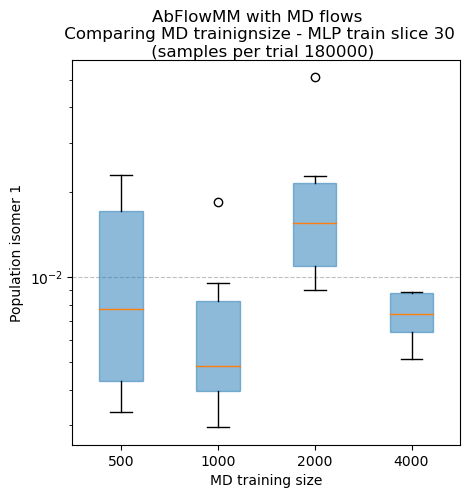

In [8]:
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 1000, 2000, 4000]
flow_train_slices = [0] #, 12, 18, 24, 30]
mlp_train_slices = [30] #[0]
sample_size = 180000

plt.figure(figsize=(5, 5))
handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
ax = plt.subplot(111)
plt.suptitle('AbFlowMM with MD flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

# AbFlowMM results - flow training slice -1

for f,flow_train_slice in enumerate(flow_train_slices):
    pop_isomer_1s = []
    labels = []
    for md_training_size in md_training_sizes:
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))
    
        labels.append('{:d}'.format(md_training_size))
        df_md = df.loc[df['kind'] == 'MD']
        df_md = df_md.loc[df_md['md_training_size'] == md_training_size]
        df_md = df_md.loc[df_md['flow_train_slice'] == flow_train_slice]
        df_md = df_md.loc[df_md['sample_size'] == sample_size]

        pop_isomer_1 = df_md['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
        
    # plt.sca(axs[0])
    # plt.title('- FE isomer 0'.format(sample_size))
    # plt.boxplot(pop_isomer_1, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[0].set_axisbelow(True)
    # axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.sca(ax)
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(f), color = "C{:d}".format(f), alpha=0.5),
                )
    # red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    # handles.append(red_patch)

    plt.xlabel('MD training size')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.yscale('log')
    plt.ylabel('Population isomer 1')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_0 / Z_1 ')
    # plt.boxplot(zrs, labels=labels,
    #             # patch_artist = True,
    #             # boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

# plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

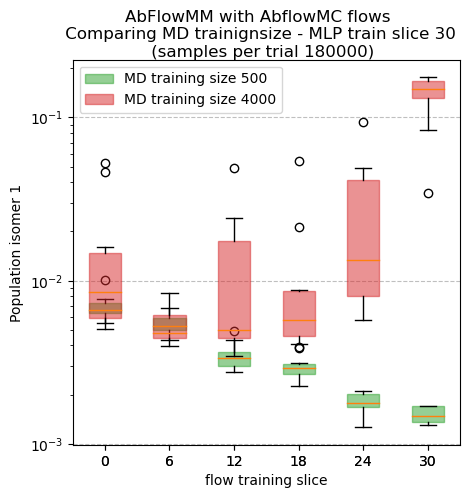

In [9]:
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-abmc-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 180000	
flow_train_slices = [0, 6, 12, 18, 24, 30]

plt.figure(figsize=(5, 5))
handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
ax = plt.subplot(111)
plt.suptitle('AbFlowMM with AbflowMC flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
        
    # plt.sca(axs[0])
    # plt.title('- FE isomer 0'.format(sample_size))
    # plt.boxplot(pop_isomer_1, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[0].set_axisbelow(True)
    # axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.sca(ax)
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.yscale('log')
    plt.ylabel('Population isomer 1')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_0 / Z_1 ')
    # plt.boxplot(zrs, labels=labels,
    #             # patch_artist = True,
    #             # boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

# 2 - deepBAR

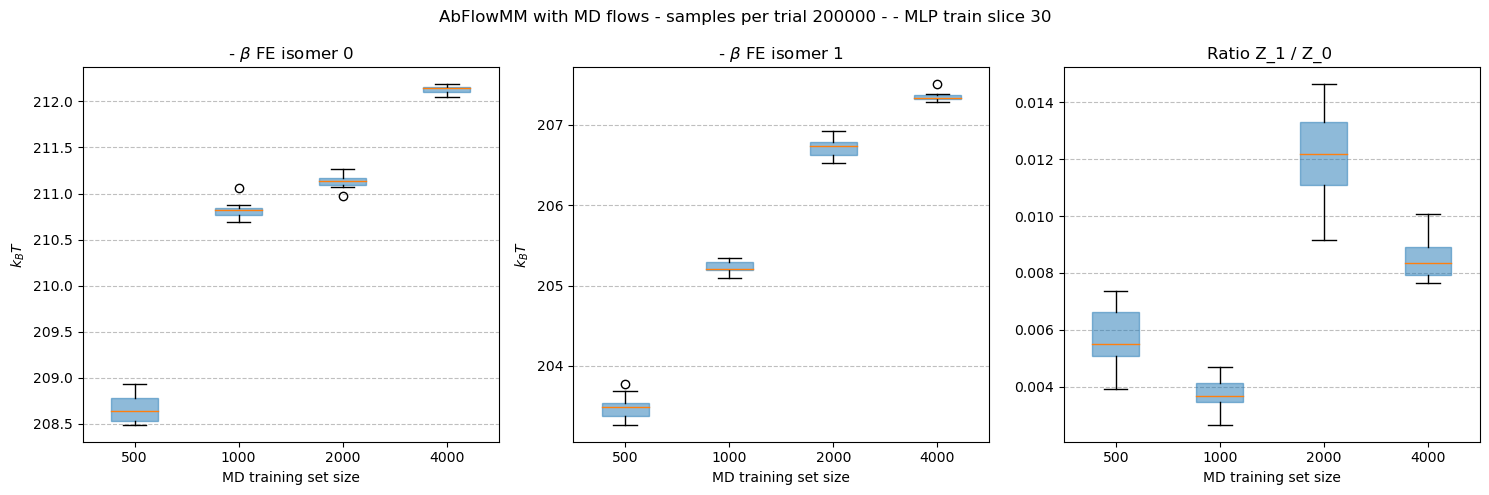

In [10]:
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000]
sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []


plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with MD flows - samples per trial {:d} - - MLP train slice {:d}'.format(sample_size, mlp_train_slice))


for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        
plt.sca(axs[0])
plt.title(r'- $\beta$ FE isomer 0'.format(sample_size))
plt.boxplot(z0s, labels=labels,
            patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[0].set_ylabel(r'$k_B T$')

plt.sca(axs[1])
plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
plt.boxplot(z1s, labels=labels,
            patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[1].set_axisbelow(True)
axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[1].set_ylabel(r'$k_B T$')

plt.sca(axs[2])
plt.title('Ratio Z_1 / Z_0 ')
plt.boxplot(zrs, labels=labels,patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[2].set_axisbelow(True)
axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

plt.tight_layout()
plt.savefig(filename + '.png', dpi=300)

### 3.2.2 - Adaptive flows

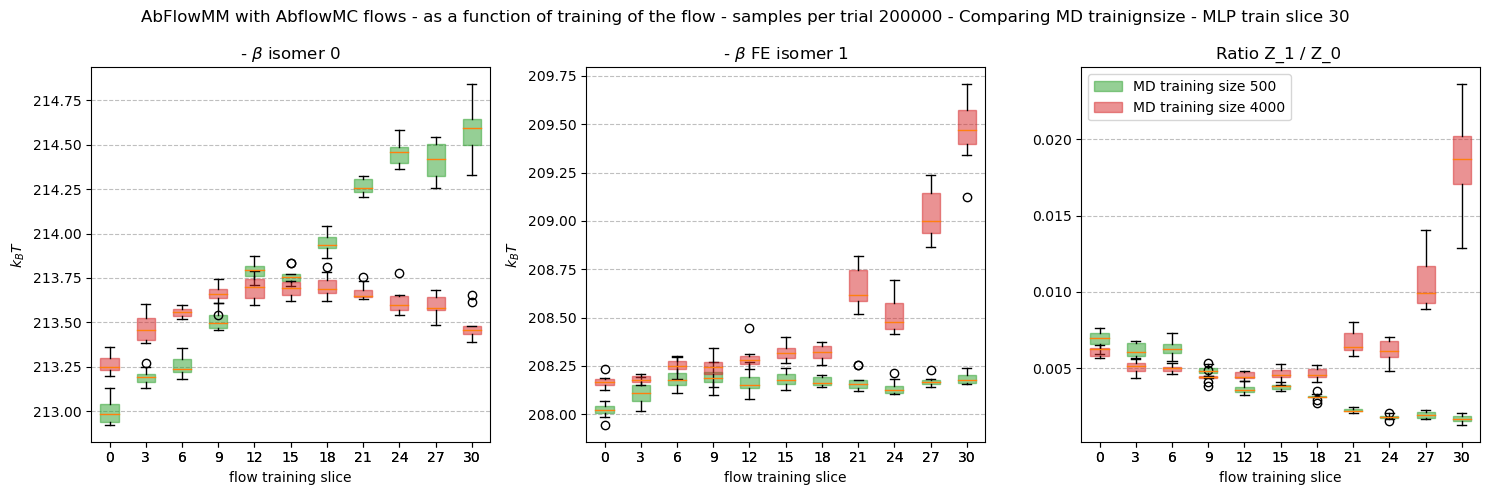

In [11]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'- $\beta$ isomer 0'.format(sample_size))
    plt.boxplot(z0s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
               
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'$k_B T$')
    
    plt.sca(axs[1])
    plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
    plt.boxplot(z1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[1].set_ylabel(r'$k_B T$')

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()
plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

## 4 - Putting MCMC + BAR together for the relative populations

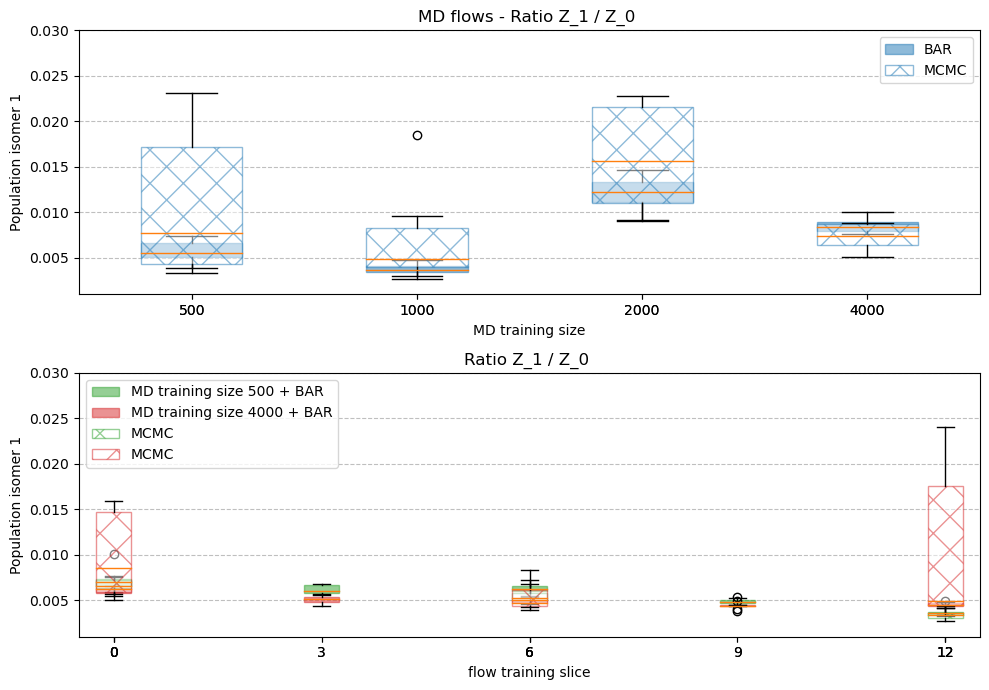

In [59]:
plt.figure(figsize=(10, 7))
axs = [plt.subplot(211),plt.subplot(212)]
# plt.suptitle('AbFlowMM with MD flows - samples per trial {:d} - - MLP train slice {:d}'.format(sample_size, mlp_train_slice))


### MD FLOWS BAR
handles = []
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000]
sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []


for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

plt.sca(axs[0])
plt.title('MD flows - Ratio Z_1 / Z_0 ')
plt.boxplot(zrs, labels=labels,patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

red_patch = mpatches.Patch(color = "C0".format(m+2), alpha=0.5, label='BAR')
handles.append(red_patch)


## MD Flows MCMCs

mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 1000, 2000, 4000]
flow_training_slices = [0] #, 12, 18, 24, 30]
mlp_train_slices = [30] #[0]
sample_size = 180000


for f,flow_train_slice in enumerate(flow_train_slices):
    pop_isomer_1s = []
    labels = []
    for md_training_size in md_training_sizes:
     
        labels.append('{:d}'.format(md_training_size))
        df_md = df.loc[df['kind'] == 'MD']
        df_md = df_md.loc[df_md['md_training_size'] == md_training_size]
        df_md = df_md.loc[df_md['flow_train_slice'] == flow_train_slice]
        df_md = df_md.loc[df_md['sample_size'] == sample_size]

        pop_isomer_1 = df_md['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
    
    plt.sca(axs[0])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "w", color = "C{:d}".format(f), hatch = 'x', alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", edgecolor = "C{:d}".format(f), hatch = 'x', alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('MD training size')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)


plt.legend(handles=handles)

##############################################################
#### ABMC FLOWS BAR

# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = [0, 3, 6, 9, 12] #, 15, 18, 21, 24, 27, 30]

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[1])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d} + BAR'.format(md_training_size))
    handles.append(red_patch)


###### ABMC FLOWS MCMC
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-abmc-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 180000	
flow_train_slices = [0, 6, 12]  #, 18, 24, 30]

# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        

    plt.sca(axs[1])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "w", hatch='x', color = "C{:d}".format(m+2), alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", hatch='x', edgecolor = "C{:d}".format(m+2), alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)



plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

    

plt.legend(handles=handles)




plt.tight_layout()
# plt.savefig(filename + '.png', dpi=300)

# 5 - Free energy 

0 Isomer 0 
 Absolute Free Energy
1 Isomer 1 
 Absolute Free Energy
2 Population Isomer 1


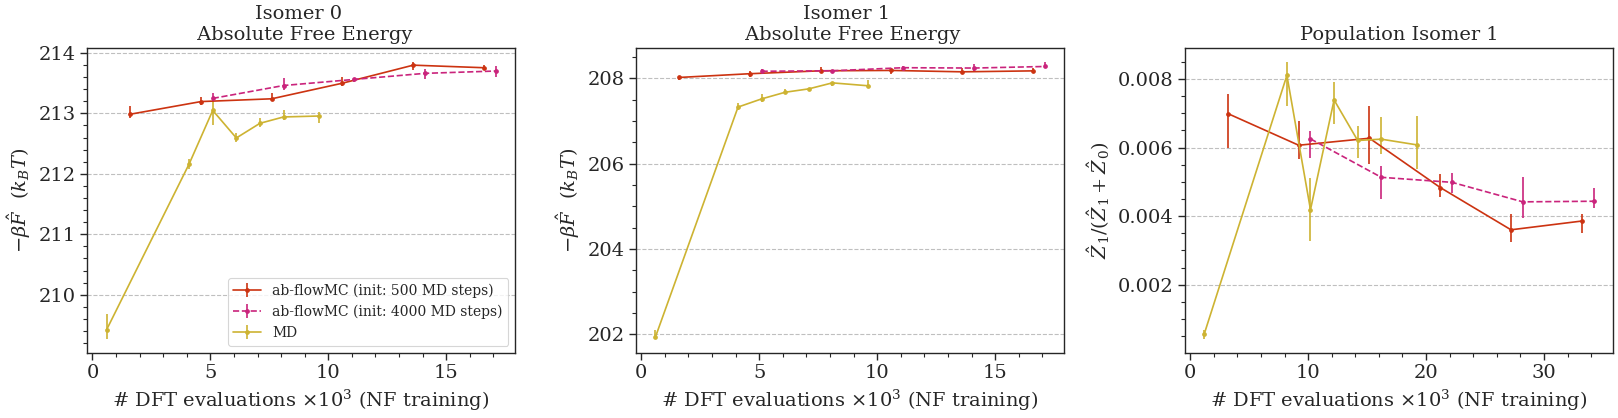

In [69]:
#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))



figsize=(5.5*3, 1.5*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=10
linewidth=2
markersize=5
hspace=0.2
wspace=0.4

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, ylabel=r'$k_B T$', ls='-', label=None):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]
    
    # Plot errorbar
    ax.errorbar(positions/10**3, medians, yerr=errors, fmt='.', color=color, label=label, linestyle=ls)
    
    ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$ (NF training) ')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
flow_train_slices = np.array([0, 3, 6, 9, 12, 15]) #, 18]) #, 21, 24, 27, 30])

plt.figure(figsize=figsize)
axs = [plt.subplot(1, 3, i + 1) for i in range(3)]
# plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainingsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []

lss = ['-', '--']

# AbFlowMM results - flow training slice -1
for m, md_training_size in enumerate(md_training_sizes):
    label='ab-flowMC (init: {:d} MD steps)'.format(md_training_size)
    z0s, z1s, zrs = [], [], []

    if m == 1:
        flow_train_slices = flow_train_slices[:-1]

    for flow_train_slice in flow_train_slices:

        # labels = ['{:d}'.format(flow_train_slice)]
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

    positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['- $\\beta$ isomer 0', '- $\\beta$ FE isomer 1', 'Isomer 1 population'])):
        
        if i == 2:
            positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference

        plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label], label=label, ls=lss[m])

    # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

########### ADDING MD results
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-22-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
sample_size = 200000
flow_train_slices = [0]

z0s, z1s, zrs = [], [], []

for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        # labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
label = 'MD'
positions = np.array(md_training_sizes) + 100
for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Isomer 0 \n Absolute Free Energy', 'Isomer 1 \n Absolute Free Energy', 'Population Isomer 1'])):
    print(i, subplot_title)

    ylabel = r"$-\beta \hat F$  ($k_B T$)"
    if i == 2:
        positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
        ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

    plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel)

# handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

# Adding legend
# plt.legend(handles=handles)
plt.sca(axs[0])
plt.legend(fontsize=size_legend)
plt.tight_layout()
plt.savefig('paper_figures/absolute_free_energies.pdf')


# 7 - Test likelihood, free energies and overfitting

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/789419696.py:84: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/789419696.py:85: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_21747/789419696.py:86: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)


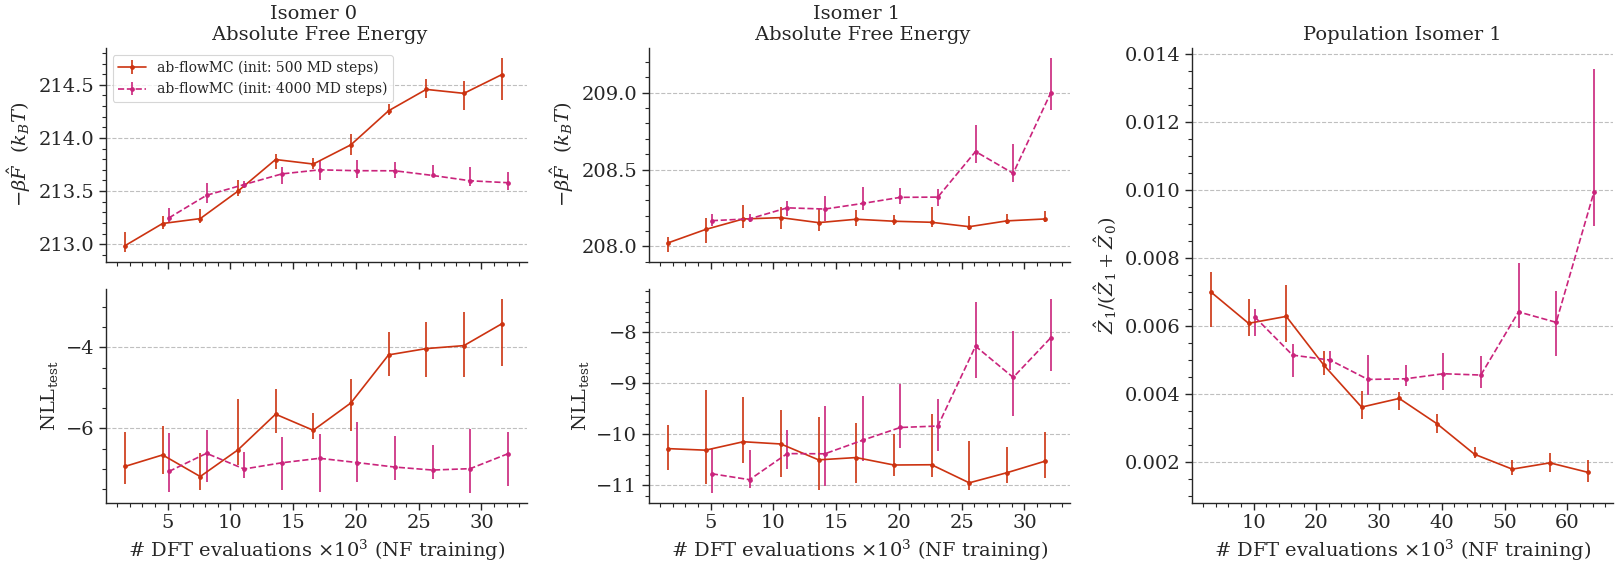

In [94]:
#BOXPLOT
# def plot_subplot(ax, title, data, positions, color_index, label):
#     ax.set_title(title)
#     box_plot = ax.boxplot(data, positions=positions,
#                           patch_artist=True,
#                           widths=1000,
#                           boxprops=dict(facecolor="C{:d}".format(color_index), color="C{:d}".format(color_index), alpha=0.5),
#                           whiskerprops=dict(color="C{:d}".format(color_index)),
#                           medianprops=dict(color='black'),
#                           flierprops=dict(marker='d', markersize=5, alpha=0.5, markeredgecolor="C{:d}".format(color_index), markerfacecolor="C{:d}".format(color_index))
#                           )
#     ax.plot(positions, np.median(data, axis=1), color="C{:d}".format(color_index), linewidth=1, linestyle='--')
#     ax.set_xlabel('$\#$ DFT evaluations during training')
#     ax.set_axisbelow(True)
#     ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
#     ax.set_ylabel(r'$k_B T$')
#     ax.set_xticks(np.linspace(0, 20400, num=6))
#     ax.set_xticklabels(np.linspace(0, 20400, num=6))
#     ax.xaxis.set_major_formatter(StrMethodFormatter('{x: .0f}'))



figsize=(5.5*3, 2*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=10
linewidth=2
markersize=5
hspace=0.2
wspace=0.

sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   


def plot_subplot(ax, title, data, positions, color, ylabel=r'$k_B T$', ls='-',
                 label=None,drawxlabel=True):
    ax.set_title(title)
    
    # Using plt.errorbar instead of boxplot
    # Calculate median and interquartile range (IQR)
    medians = np.median(data, axis=1)
    q1 = np.percentile(data, 5, axis=1)
    q3 = np.percentile(data, 95, axis=1)
    
    # Calculate errors for errorbar
    errors = [medians - q1, q3 - medians]
    
    # Plot errorbar
    ax.errorbar(positions/10**3, medians, yerr=errors, fmt='.', color=color, 
                label=label, linestyle=ls)
    
    if drawxlabel:
        ax.set_xlabel(r'$\#$ DFT evaluations $\times 10^{3}$ (NF training)')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    ax.set_ylabel(ylabel)


mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
sample_size = 200000

filename = subproject_path + '9-mcmc-bar/2023-12-22-test-losses-abmc-flows-mlpmodel{:d}'.format(mlp_train_slice)
df_test = pd.read_csv(filename + '.csv') 
sample_size_test = 18000

md_training_sizes = [500, 4000]

flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
# flow_train_slices = np.array([0, 3, 6, 9, 12, 15]) #, 18]) #, 21, 24, 27, 30])

fig = plt.figure(figsize=figsize)
fig.subplots_adjust(hspace=0)
# subplot2grid with 3 columns and 2 rows (3x2 grid)
axs = [plt.subplot(2, 3, i + 1) for i in range(5)]
axs[3] = plt.subplot2grid((2, 3), (1, 0), sharex=axs[0])
axs[4] = plt.subplot2grid((2, 3), (1, 1), sharex=axs[1])
axs[2] = plt.subplot2grid((2, 3), (0, 2), colspan=1, rowspan=2)


# axs = [plt.subplot(2, 3, i + 1) for i in range(6)]
# plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainingsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []

lss = ['-', '--']

# AbFlowMM results - flow training slice -1
for m, md_training_size in enumerate(md_training_sizes):
    label='ab-flowMC (init: {:d} MD steps)'.format(md_training_size)
    z0s, z1s, zrs = [], [], []
    test_loss_0s, test_loss_1s = [], []

    if m == 1:
        flow_train_slices = flow_train_slices[:-1]

    for flow_train_slice in flow_train_slices:

        # labels = ['{:d}'.format(flow_train_slice)]
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0, z_1 = (-log_r_0), (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        df_abflow = df_test.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size_test]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        test_loss_0 = df_abflow_0['test_losses'].values
        test_loss_1 = df_abflow_1['test_losses'].values

        test_loss_0s.append(test_loss_0)
        test_loss_1s.append(test_loss_1)

    ylabel = r"$-\beta \hat F$  ($k_B T$)"
    positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Isomer 0 \n Absolute Free Energy', 'Isomer 1 \n Absolute Free Energy', 'Population Isomer 1'])):
        drawxlabel=False
        if i == 2:
            positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
            ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'
            drawxlabel=True

        plot_subplot(axs[i], subplot_title, z_data, positions, model_colors[label], 
                     label=label, ls=lss[m], ylabel=ylabel, drawxlabel=drawxlabel)

    ylabel = r'NLL$_{\mathrm{test}}$'
    positions = (flow_train_slices + 1) * 20 * 50 + md_training_size + 100
    for i, (z_data, subplot_title) in enumerate(zip([test_loss_0s, test_loss_1s], [None, None])):
        
        if i == 2:
            positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
            ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

        plot_subplot(axs[i + 3], subplot_title, z_data, positions, model_colors[label], label=label, ls=lss[m], ylabel=ylabel)

    # handles.append(mpatches.Patch(color="C{:d}".format(m + 2), alpha=0.5, label=label))

########### ADDING MD results
# mlp_train_slice = 30

# filename = subproject_path + '9-mcmc-bar/2023-12-22-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
# df = pd.read_csv(filename + '.csv')
# md_training_sizes = [500, 4000, 5000, 6000, 7000, 8000, 9500]
# sample_size = 200000
# flow_train_slices = [0]

# z0s, z1s, zrs = [], [], []

# for md_training_size in md_training_sizes:
#     for flow_train_slice in flow_train_slices:
#         # labels.append('{:d}'.format(md_training_size))
#         df_abflow = df.loc[df['kind'] == 'MD']
#         df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
#         df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
#         df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
#         df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

#         df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
#         df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

#         log_r_0 = df_abflow_0['log_r'].values
#         log_r_1 = df_abflow_1['log_r'].values

#         z_r = np.exp(log_r_0 - log_r_1)
#         zrs.append(z_r)

#         z_0, z_1 = (-log_r_0), (-log_r_1)
#         z0s.append(z_0)
#         z1s.append(z_1)
# label = 'MD'
# positions = np.array(md_training_sizes) + 100
# for i, (z_data, subplot_title) in enumerate(zip([z0s, z1s, zrs], ['Isomer 0 \n Absolute Free Energy', 'Isomer 1 \n Absolute Free Energy', 'Population Isomer 1'])):
#     print(i, subplot_title)

#     ylabel = r"$-\beta \hat F$  ($k_B T$)"
#     if i == 2:
#         positions = 2 * positions #needs twice the number of evaluations to compute the free energy difference
#         ylabel = r'$\hat Z_1 / (\hat Z_1 + \hat Z_0)$'

#     plot_subplot(axs[i], subplot_title, z_data, positions, model_colors['MD'], label=label, ylabel=ylabel)

# handles.append(mpatches.Patch(color="C0", alpha=0.5, label='MD'))

# Adding legend
# plt.legend(handles=handles)

for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)
for a in range(2):
    plt.setp(axs[a].get_xticklabels(), visible=False)

plt.sca(axs[0])
plt.legend(fontsize=size_legend)
plt.tight_layout()
plt.savefig('paper_figures/free_energies_and_overfitting.pdf')


In [60]:
test_loss_0s

[array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64)]

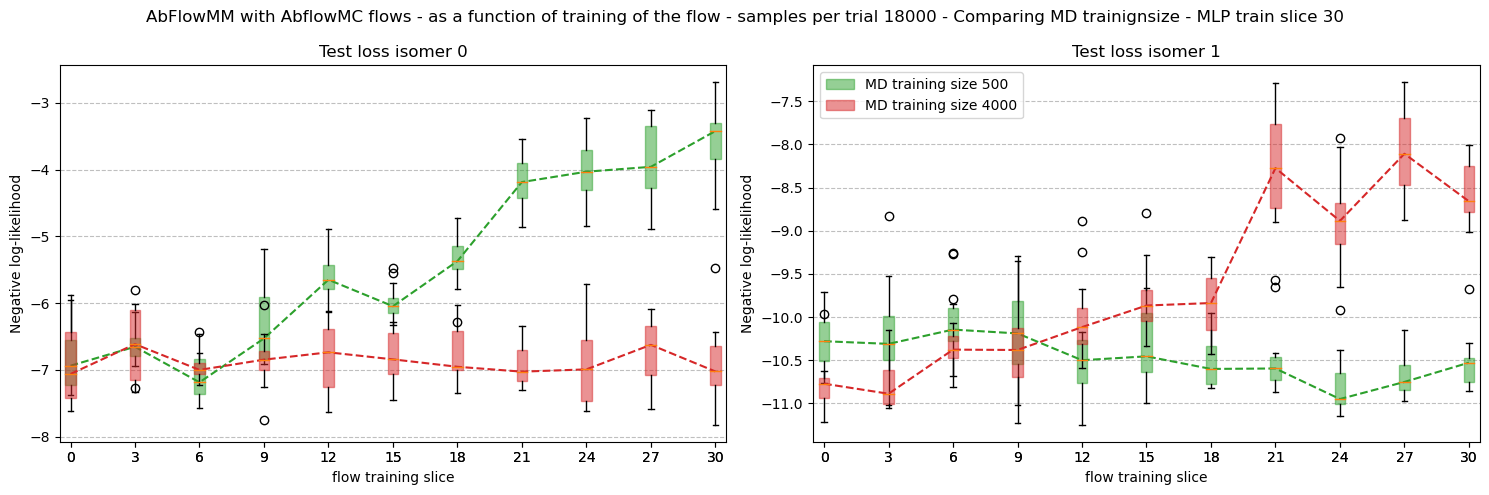

In [57]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-22-test-losses-abmc-flows-mlpmodel{:d}'.format(mlp_train_slice)
df_test = pd.read_csv(filename + '.csv') 
# df = pd.DataFrame(dic_results_test_abmc_flows)
md_training_sizes = [500, 4000]
# sample_size = 20000
sample_size = 18000
flow_train_slices = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    test_loss_0s = []
    test_loss_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df_test.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        test_loss_0 = df_abflow_0['test_losses'].values
        test_loss_1 = df_abflow_1['test_losses'].values

        test_loss_0s.append(test_loss_0)
        test_loss_1s.append(test_loss_1)

        
    plt.sca(axs[0])
    plt.title(r'Test loss isomer 0'.format(sample_size))
    plt.boxplot(test_loss_0s,
                positions=flow_train_slices,
                # labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    # plot median
    plt.plot(flow_train_slices, np.median(test_loss_0s, axis=1), color='C{:d}'.format(m+2), linestyle='--')
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'Negative log-likelihood')
    
    plt.sca(axs[1])
    plt.title(r'Test loss isomer 1'.format(sample_size))
    plt.boxplot(test_loss_1s,
                positions=flow_train_slices,
                # labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    # plot median
    plt.plot(flow_train_slices, np.median(test_loss_1s, axis=1), color='C{:d}'.format(m+2), linestyle='--')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.xlabel('flow training slice')
    axs[1].set_ylabel(r'Negative log-likelihood')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_1 / Z_0 ')
    # plt.boxplot(zrs, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
    #             )
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)